Comenzaremos con la preparación del dataset previa a la implementación del modelo. El primer paso será la importación de las librerías necesarias y el dataset objetivo.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("generacion_meteo_merged2min.csv", sep=";")

data.head() #Mostramos primeras filas

,datetime,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
0,24/01/2025 13:10,65,17.6 °C,24.1 km/h,100 W/m²,55 %H,0 mm,29.9 hPa
1,24/01/2025 13:15,70,17.6 °C,22.5 km/h,105 W/m²,54 %H,0 mm,29.9 hPa
2,24/01/2025 13:20,76,17.7 °C,33.8 km/h,111 W/m²,54 %H,0 mm,29.9 hPa
3,24/01/2025 13:25,82,17.7 °C,17.7 km/h,114 W/m²,53 %H,0 mm,29.9 hPa
4,24/01/2025 13:30,78,17.7 °C,27.4 km/h,105 W/m²,53 %H,0 mm,29.9 hPa


- datetime: Fecha
- Power_gen: Potencia generada en kilovatios
- temperature: Temperatura en grados celsius
- windSpeed: Velocidad del viento en kilómetros/hora
- solarRad: Irradiancia solar en vatios/metro cuadrado
- humedad: Porcentaje de humedad
- rain: Lluvia en milímetros
- pressure: Presión en hectopascales

Visualizamos información referente al dataset.

In [59]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46712 entries, 0 to 46711
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   datetime     46712 non-null  object
 1   Power_gen    46712 non-null  int64 
 2   temperature  33244 non-null  object
 3   windSpeed    33244 non-null  object
 4   solarRad     33245 non-null  object
 5   humedad      33244 non-null  object
 6   rain         33244 non-null  object
 7   pressure     33244 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.9+ MB


Como necesitaremos las columnas en valores numéricos, debemos pasar las de tipo objeto a tipo float antes de continuar.

In [60]:
cols = [c for c in data.columns if c != "datetime"]

#Antes de pasar a float, limpiamos los datos (eliminando las unidades y dejando solo el valor numérico)
for c in cols:
    s = data[c].astype(str)
    s = s.str.replace(r"[^0-9\.,-]", "", regex=True)
    s = s.str.replace(",", ".", regex=False)
    data[c] = pd.to_numeric(s, errors="coerce")

data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46712 entries, 0 to 46711
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     46712 non-null  object 
 1   Power_gen    46712 non-null  int64  
 2   temperature  33244 non-null  float64
 3   windSpeed    33244 non-null  float64
 4   solarRad     33245 non-null  float64
 5   humedad      33244 non-null  float64
 6   rain         33244 non-null  float64
 7   pressure     33244 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 2.9+ MB


Ahora que tenemos los datos limpios y en formato numérico, mostramos la descripción estadística para observar valores como la media, máximo, ...

In [61]:
data.describe()

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
count,46712.000000,33244.000000,33244.000000,33245.000000,33244.000000,33244.000000,33244.000000
mean,254.437018,115.637084,32.079923,2086.304557,85.190982,37.057460,30.088551
std,243.557124,406.582939,91.386588,7399.021252,42.658934,136.455969,0.911979
min,0.000000,4.440000,0.000000,0.000000,29.000000,0.000000,0.000000
25%,39.000000,14.400000,4.830000,77.000000,69.000000,0.000000,30.000000
50%,153.000000,18.200000,8.050000,243.000000,78.000000,0.000000,30.100000
75%,457.000000,21.600000,16.100000,559.000000,86.000000,2.200000,30.300000
max,780.000000,1803.000000,410.000000,32767.000000,255.000000,800.000000,30.700000


Observamos que hay valores claramente erróneos que alteran los resultados (temperature=1803, windSpeed=410,...). Posteriormente los trataremos.

Histograma:

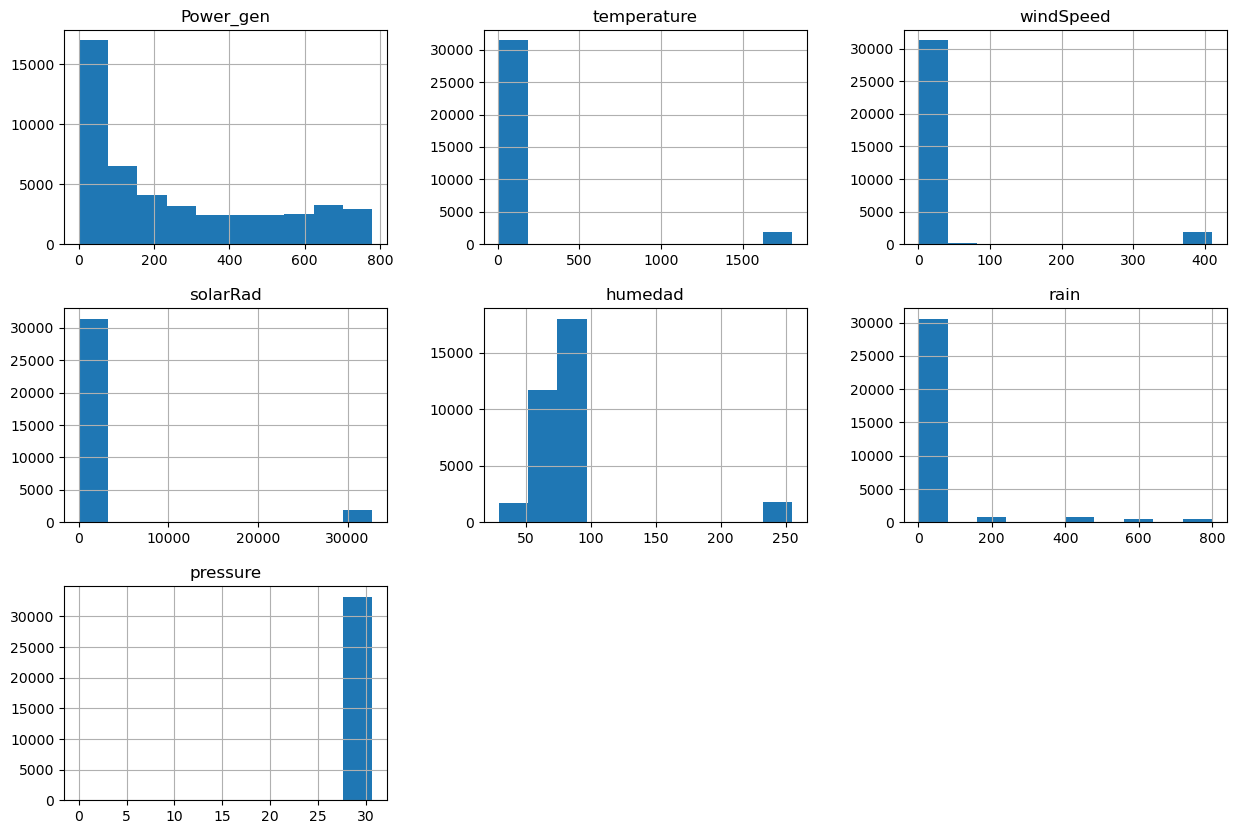

In [62]:
histograma = data.hist(figsize=(15, 10))

Podemos observar que los valores de todas las variables se concentran mayoritariamente en una parte del histograma, con valores extraordinarios muy alejados de esta. Power_gen y pressure son la excepción, ya que si presentan histogramas razonables.

Con violinplots se observa claramente:

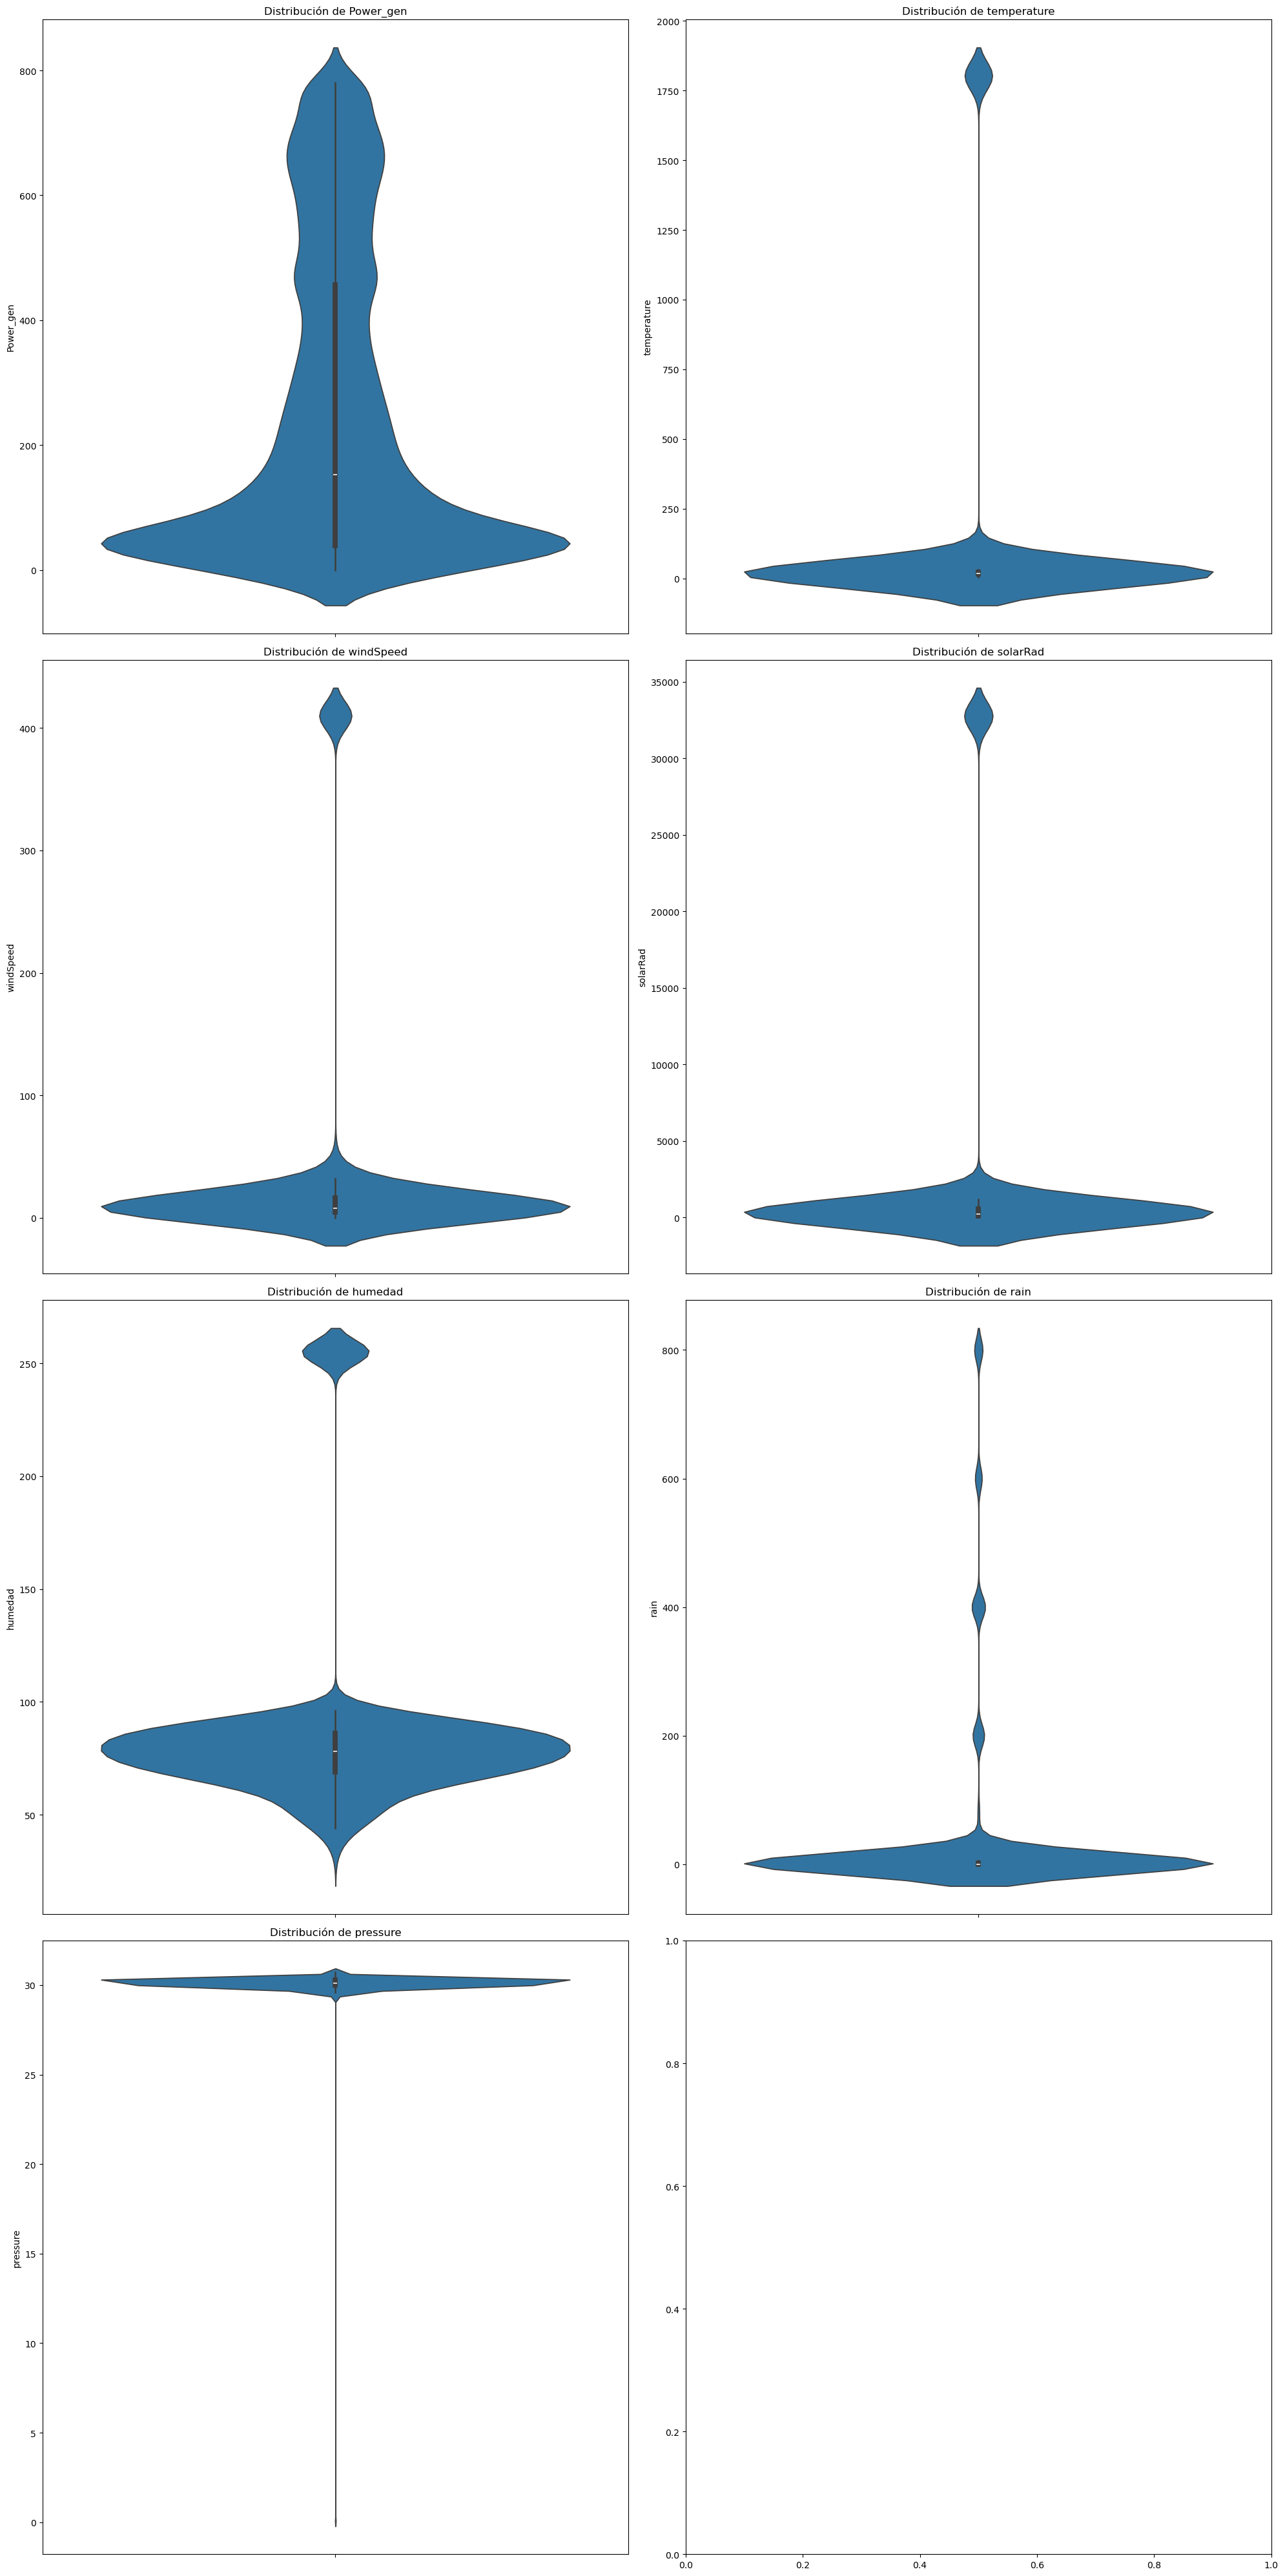

In [63]:
#Creamos una lista con las variables numéricas (todas menos datetime)
numeric_cols = data.drop(columns=['datetime'])

#Numero de filas y columnas para los subplots
filas, columnas =4,2

#Creamos figura y ejes para los subplots
fig,axes = plt.subplots(filas, columnas, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    sns.violinplot(y=numeric_cols[col], ax=axes[i])

for ax, col in zip(axes, numeric_cols):
    ax.set_title(f'Distribución de {col}')


plt.tight_layout()
plt.show()

Como los outliers alteran enormemente el resultado del modelo, hemos de eliminarlos del dataset.

Para calcular los outliers, hemos de calcular primero el IQR de cada variable. Esto es la diferencia entre el percentil 75 y el percentil 25, de forma que el valor resultante representa el rango en el que se encuentra el 50% central de los datos. Normalmente, se consideran outliers los valores por debajo de (percentil 25 - 1.5 * IQR) o por encima de (percentil 75 + 1.5 * IQR).

In [64]:
outlier_cols = data.select_dtypes(include=[np.number]).columns

P25 = data[outlier_cols].quantile(0.25) #Percentil 25
P75 = data[outlier_cols].quantile(0.75) #Percentil 75
IQR = P75 - P25 #Interquartile Range


#Identificar outliers
outliers = ((data[outlier_cols] < (P25 - 1.5 * IQR)) | (data[outlier_cols] > (P75 + 1.5 * IQR)))
print(outliers.sum())

Power_gen         0
temperature    1927
windSpeed      2380
solarRad       1825
humedad        2271
rain           5473
pressure        371
dtype: int64


Con los outliers detectados, procedemos a eliminarlos del dataset.

In [65]:
data = data.loc[~outliers.any(axis=1)].reset_index(drop=True)

Volvemos a mostrar los histogramas y violinplots para ver el resultado

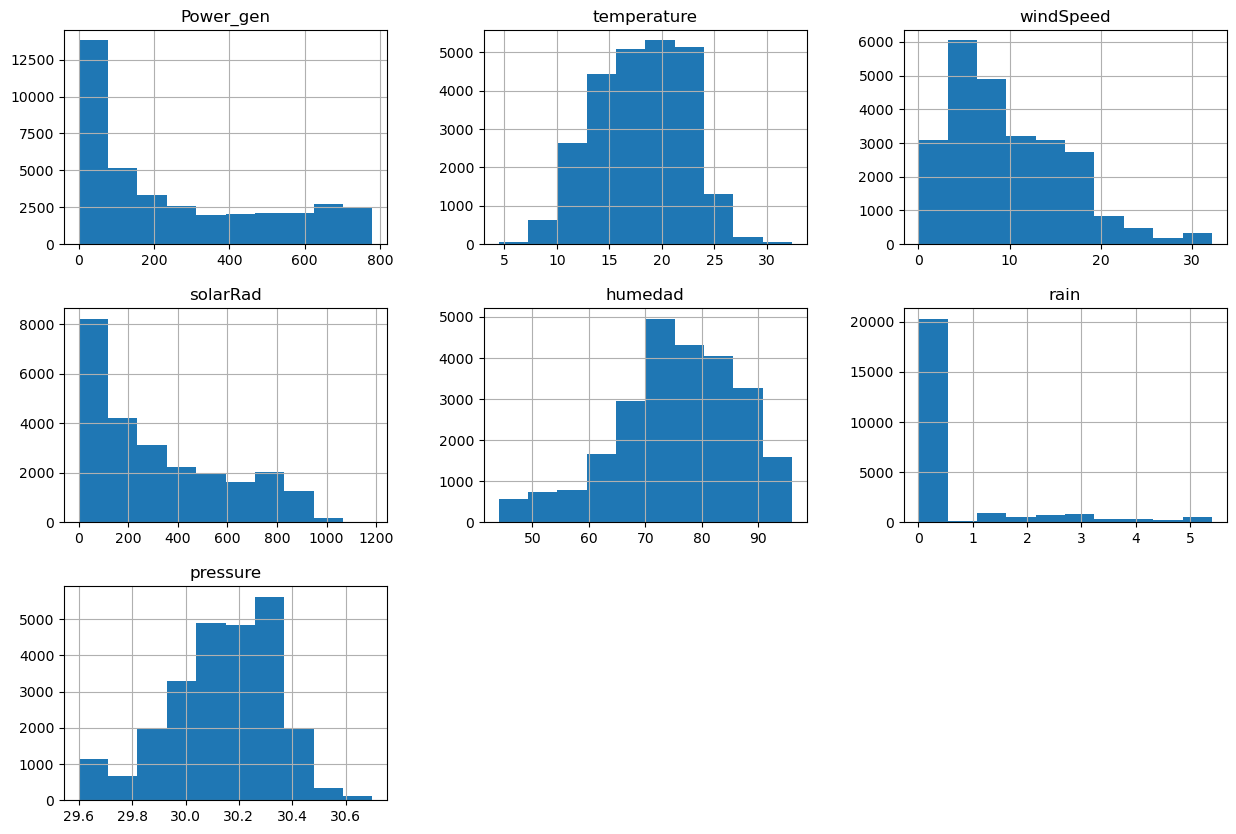

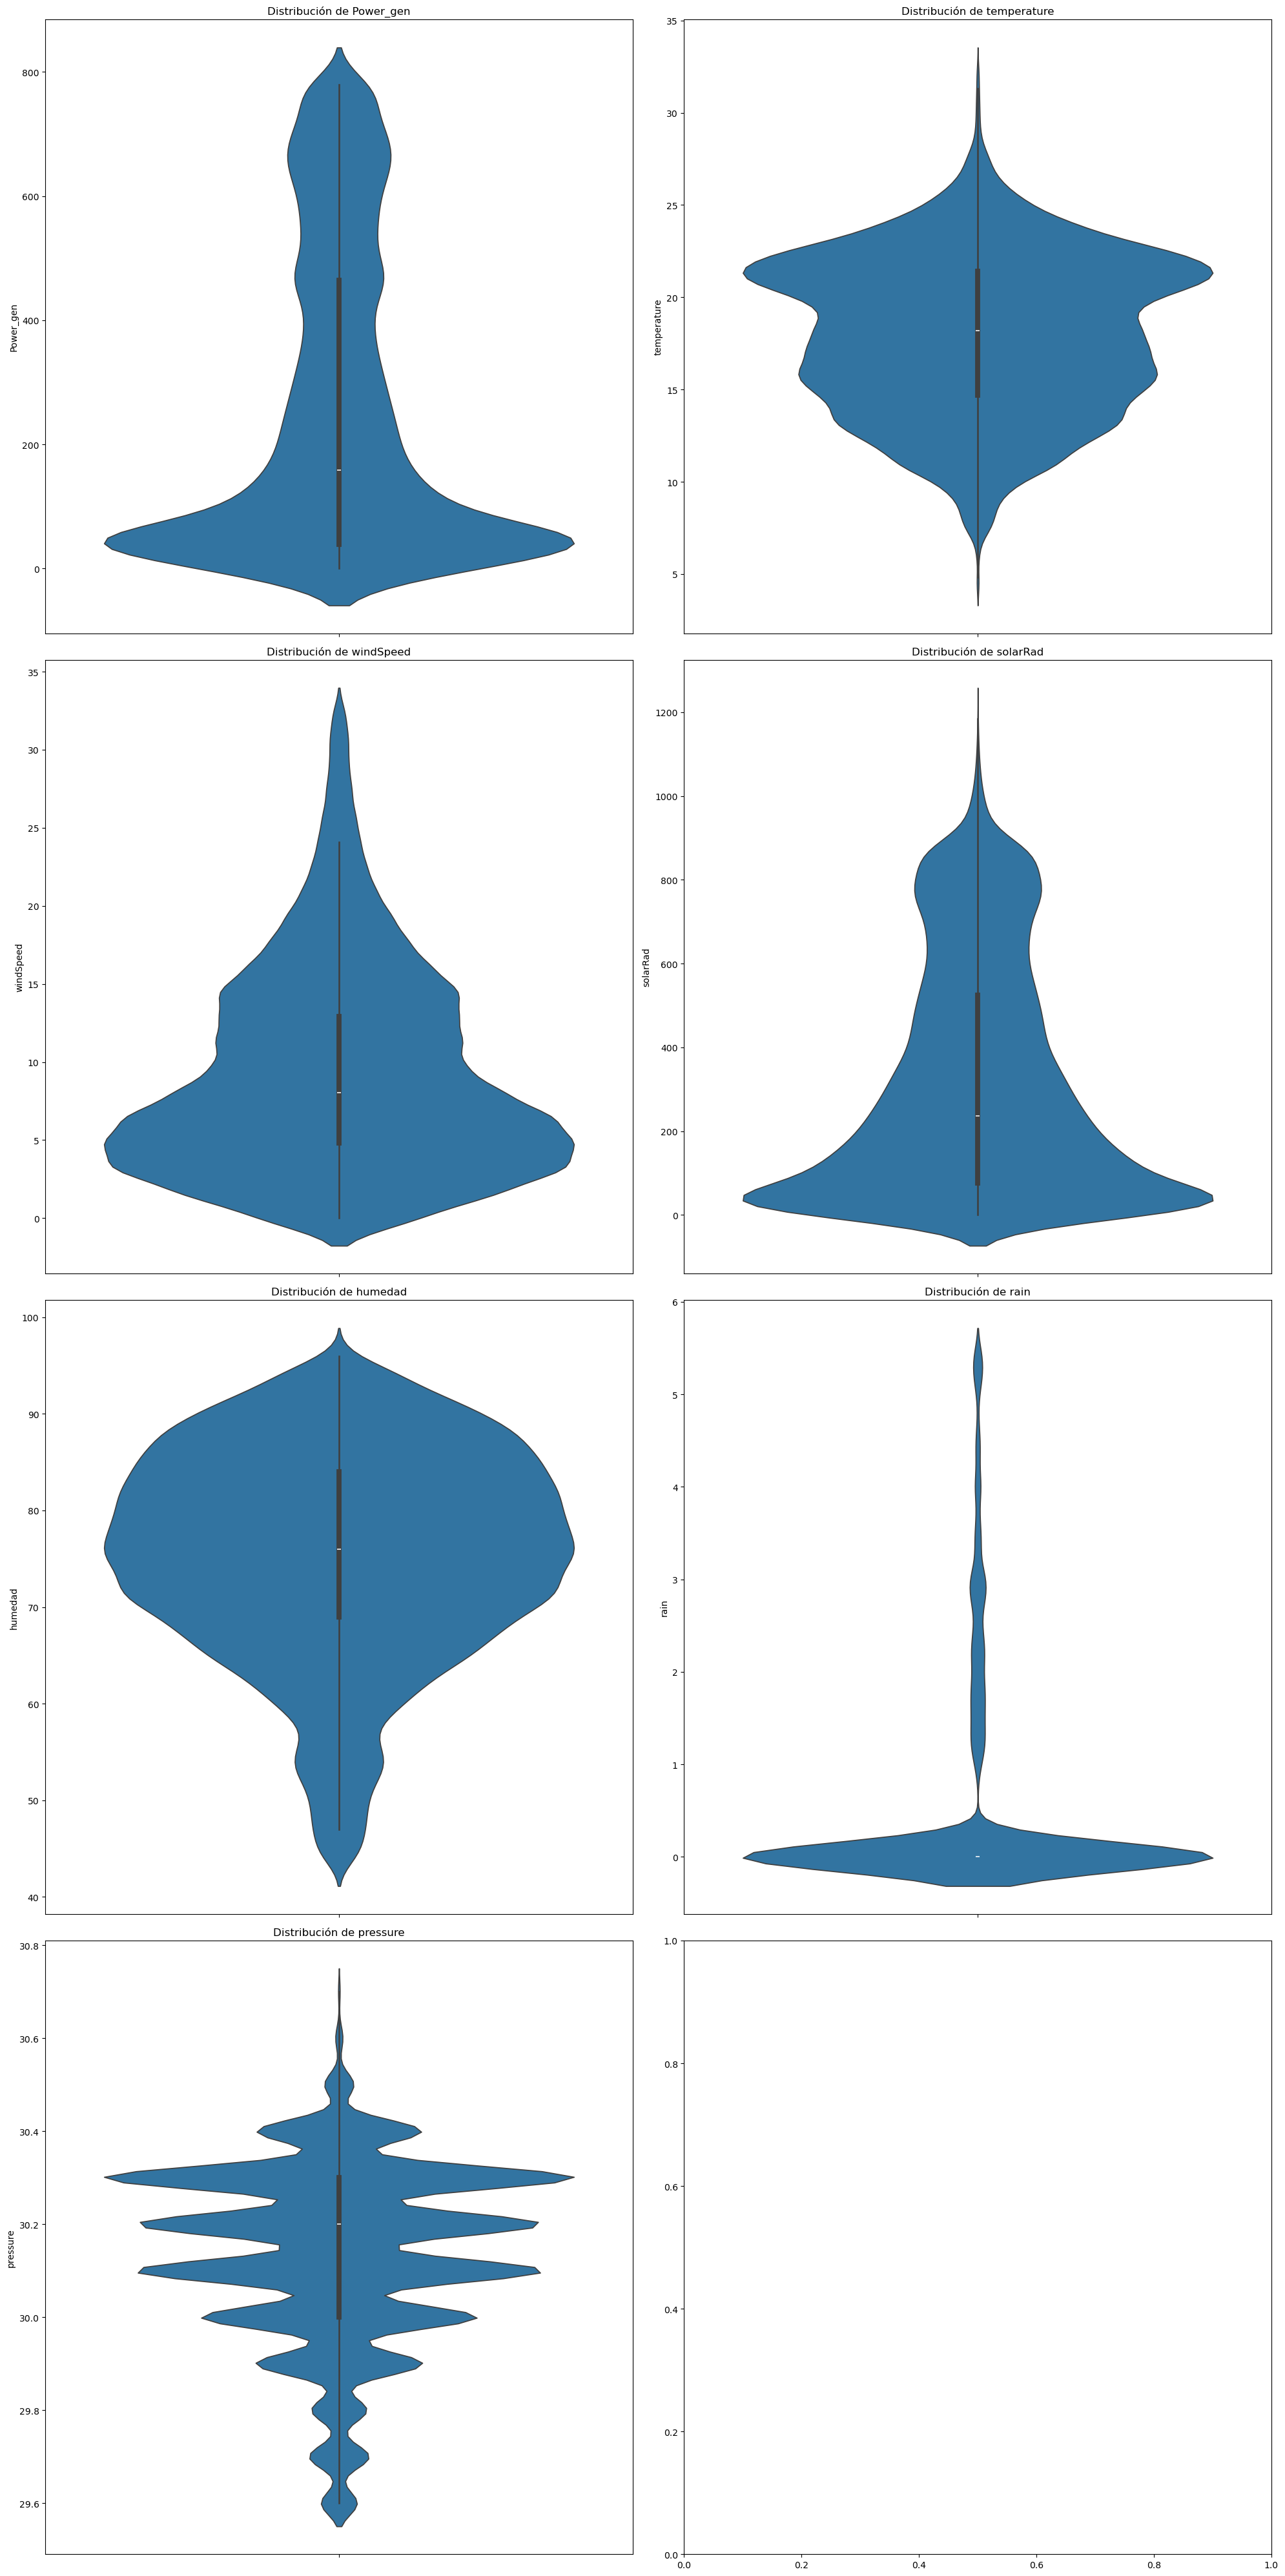

In [66]:
histograma = data.hist(figsize=(15, 10))

#Creamos una lista con las variables numéricas (todas menos datetime)
numeric_cols = data.drop(columns=['datetime'])

#Numero de filas y columnas para los subplots
filas, columnas =4,2

#Creamos figura y ejes para los subplots
fig,axes = plt.subplots(filas, columnas, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    sns.violinplot(y=numeric_cols[col], ax=axes[i])

for ax, col in zip(axes, numeric_cols):
    ax.set_title(f'Distribución de {col}')


plt.tight_layout()
plt.show()

Consultamos la nueva información y descripción analítica.

In [67]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38319 entries, 0 to 38318
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     38319 non-null  object 
 1   Power_gen    38319 non-null  int64  
 2   temperature  24851 non-null  float64
 3   windSpeed    24851 non-null  float64
 4   solarRad     24852 non-null  float64
 5   humedad      24851 non-null  float64
 6   rain         24851 non-null  float64
 7   pressure     24851 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 2.3+ MB


In [69]:
data.describe()

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
count,38319.000000,24851.000000,24851.000000,24852.000000,24851.000000,24851.000000,24851.000000
mean,258.785067,18.009530,9.276183,318.868783,75.457285,0.502716,30.138787
std,245.286221,4.302447,6.679314,277.219610,10.882762,1.196186,0.189359
min,0.000000,4.440000,0.000000,0.000000,44.000000,0.000000,29.600000
25%,39.000000,14.700000,4.830000,76.000000,69.000000,0.000000,30.000000
50%,159.000000,18.200000,8.050000,236.000000,76.000000,0.000000,30.200000
75%,464.000000,21.400000,12.900000,524.000000,84.000000,0.000000,30.300000
max,780.000000,32.400000,32.200000,1185.000000,96.000000,5.400000,30.700000


Observamos que los valores imposibles se han eliminado, dejando como resultado los valores reales.

Eliminamos filas con NaN

In [70]:
data = data.dropna()

Información y descripción del dataset final

In [71]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 24851 entries, 0 to 38305
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     24851 non-null  object 
 1   Power_gen    24851 non-null  int64  
 2   temperature  24851 non-null  float64
 3   windSpeed    24851 non-null  float64
 4   solarRad     24851 non-null  float64
 5   humedad      24851 non-null  float64
 6   rain         24851 non-null  float64
 7   pressure     24851 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.7+ MB


In [72]:
data.describe()

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure
count,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000
mean,266.836988,18.009530,9.276183,318.877590,75.457285,0.502716,30.138787
std,248.991720,4.302447,6.679314,277.221711,10.882762,1.196186,0.189359
min,0.000000,4.440000,0.000000,0.000000,44.000000,0.000000,29.600000
25%,39.000000,14.700000,4.830000,76.000000,69.000000,0.000000,30.000000
50%,172.000000,18.200000,8.050000,236.000000,76.000000,0.000000,30.200000
75%,471.000000,21.400000,12.900000,524.000000,84.000000,0.000000,30.300000
max,780.000000,32.400000,32.200000,1185.000000,96.000000,5.400000,30.700000


Para ver el grado de correlación entre las variables, usaremos un MinMaxScaler y un heatmap.

In [73]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
datascaled = data.copy()
datascaled[numeric_cols.columns] = scaler.fit_transform(datascaled[numeric_cols.columns])
datascaled.drop(columns=["datetime"], inplace=True) #Eliminamos las columnas no numéricas, datetime en este caso

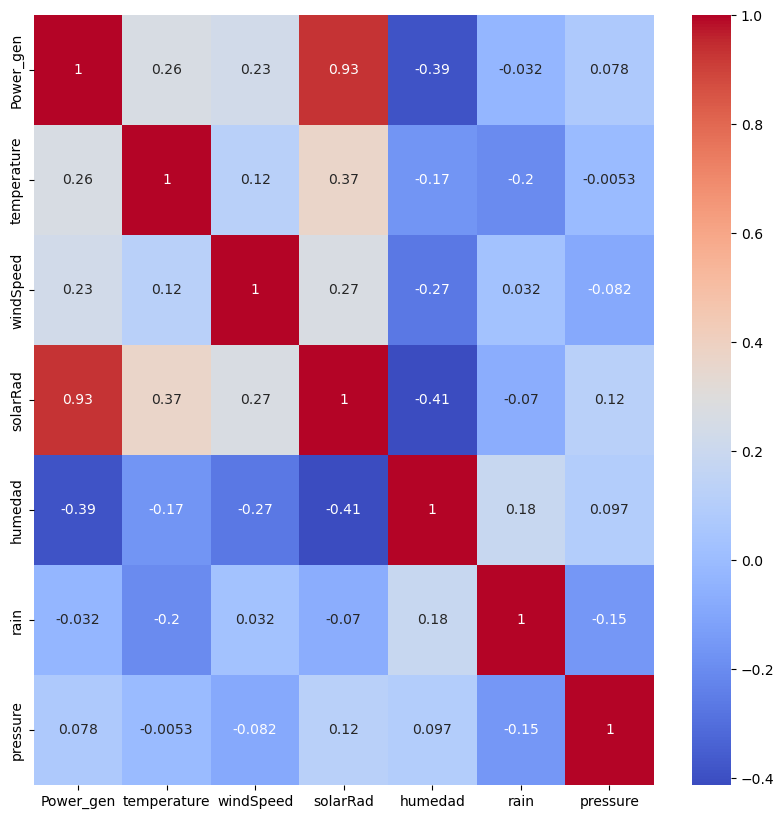

In [74]:
corr_df = datascaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Guardamos en un CSV nuevo

In [75]:
data.to_csv("CTC_processed.csv", sep=";", index=False)